In [2]:
#!/usr/bin/env python3
import pickle
import numpy as np
from pathlib import Path
from scipy.signal import butter, sosfiltfilt, find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [3]:
DATA_DIR = Path('model/wesad')

SUBJECTS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 
            'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

# Размер окна (30 секунд)
WINDOW_SIZE_SEC = 30

# Частота дискретизации (700 отсчётов в секунду)
SAMPLING_RATE = 700


In [4]:
def extract_hrv_features(ecg_segment, fs=700):
    """
    Извлекает HRV метрики из окна ECG
    
    Параметры:
        ecg_segment: кусок ECG сигнала (например, 21000 отсчётов = 30 сек)
        fs: частота (700 Hz)
    
    Возвращает:
        [SDNN, RMSSD, pNN50, Mean_HR] или None (если не удалось)
    """
    
    # Проверка: окно минимум 5 сек
    if len(ecg_segment) < int(fs * 5):
        return None
    
    try:
        # ШАГ 1: Фильтруем для R-пиков (5-15 Hz)
        sos = butter(2, [5, 15], btype='band', fs=fs, output='sos')
        ecg_band = sosfiltfilt(sos, ecg_segment)
        
        # ШАГ 2: Возводим в квадрат (усиливаем пики)
        ecg_squared = ecg_band ** 2
        
        # ШАГ 3: Интегрируем (скользящее окно 150 ms)
        window_size = int(0.15 * fs)
        ecg_integrated = np.convolve(ecg_squared, np.ones(window_size)/window_size, mode='same')
        
        # ШАГ 4: Находим R-пики
        threshold = np.mean(ecg_integrated) + 0.5 * np.std(ecg_integrated)
        r_peaks, _ = find_peaks(ecg_integrated, height=threshold, distance=int(0.4 * fs))
        
        # Проверка: минимум 10 пиков
        if len(r_peaks) < 10:
            return None
        
        # ШАГ 5: RR интервалы (в миллисекундах)
        rr_ms = np.diff(r_peaks) / fs * 1000
        
        if len(rr_ms) < 5:
            return None
        
        # ШАГ 6: Считаем HRV метрики
        sdnn = np.std(rr_ms)  # стандартное отклонение
        
        diffs = np.diff(rr_ms)
        rmssd = np.sqrt(np.mean(diffs ** 2))  # среднеквадратичная разница
        
        pnn50 = (np.sum(np.abs(diffs) > 50) / len(diffs)) * 100  # процент >50ms
        
        mean_hr = 60000 / np.mean(rr_ms)  # средний пульс
        
        return [sdnn, rmssd, pnn50, mean_hr]
    
    except Exception as e:
        return None


In [5]:
def load_subject(subject_id, window_size_sec=30, fs=700):
    """
    Загружает данные одного субъекта и извлекает признаки
    
    Параметры:
        subject_id: 'S2', 'S3', ... 'S17'
        window_size_sec: размер окна (30 сек)
        fs: частота (700 Hz)
    
    Возвращает:
        X: массив признаков (N окон × 4 признака)
        y: массив меток (N окон, 0 или 1)
    """
    
    # Путь к файлу
    subject_path = DATA_DIR / subject_id / f'{subject_id}.pkl'
    
    # Проверяем существование
    if not subject_path.exists():
        print(f"  ⚠️  {subject_id}: файл не найден")
        return None, None
    
    try:
        # ШАГ 1: Загружаем файл
        with open(subject_path, 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        
        ecg_raw = data['signal']['chest']['ECG'].flatten()
        labels = data['label'].flatten()
        
        # ШАГ 2: Фильтруем ECG (убираем шум)
        sos = butter(4, [0.5, 100], btype='band', fs=fs, output='sos')
        ecg_filtered = sosfiltfilt(sos, ecg_raw)
        
        # ШАГ 3: Разбиваем на окна по 30 сек
        window_samples = fs * window_size_sec  # 700 * 30 = 21000 отсчётов
        step_samples = window_samples // 2     # шаг 15 сек (50% перекрытие)
        
        X = []  # признаки
        y = []  # метки
        
        # Проходим по всему сигналу
        for i in range(0, len(ecg_filtered) - window_samples, step_samples):
            ecg_window = ecg_filtered[i:i+window_samples]
            label_window = labels[i:i+window_samples]
            
            # Основная метка (самая частая в окне)
            main_label = int(np.bincount(label_window.astype(int)).argmax())
            
            # Пропускаем переходные (label=0)
            if main_label == 0:
                continue
            
            # ШАГ 4: Извлекаем HRV
            hrv = extract_hrv_features(ecg_window, fs)
            
            if hrv is None:
                continue
            
            X.append(hrv)
            
            # ШАГ 5: Конвертируем метку
            # 2 = Stress → 1
            # 1, 3, 4 (Baseline, Amusement, Meditation) → 0
            y_label = 1 if main_label == 2 else 0
            y.append(y_label)
        
        X = np.array(X)
        y = np.array(y)
        
        if len(X) == 0:
            print(f"  ⚠️  {subject_id}: нет валидных окон")
            return None, None
        
        stress_count = np.sum(y)
        no_stress_count = len(y) - stress_count
        
        print(f"  ✅ {subject_id}: {len(X)} окон (Стресс: {stress_count}, Не стресс: {no_stress_count})")
        
        return X, y
    
    except Exception as e:
        print(f"  ❌ {subject_id}: ошибка - {e}")
        return None, None




                   🎓 ОБУЧЕНИЕ МОДЕЛИ НА ВСЕХ СУБЪЕКТАХ WESAD                    

📂 ЗАГРУЗКА ДАННЫХ (15 субъектов)...
--------------------------------------------------------------------------------
  ✅ S2: 201 окон (Стресс: 41, Не стресс: 160)
  ✅ S3: 212 окон (Стресс: 43, Не стресс: 169)
  ✅ S4: 206 окон (Стресс: 43, Не стресс: 163)
  ✅ S5: 210 окон (Стресс: 43, Не стресс: 167)
  ✅ S6: 209 окон (Стресс: 44, Не стресс: 165)
  ✅ S7: 209 окон (Стресс: 43, Не стресс: 166)
  ✅ S8: 210 окон (Стресс: 45, Не стресс: 165)
  ✅ S9: 212 окон (Стресс: 43, Не стресс: 169)
  ✅ S10: 216 окон (Стресс: 49, Не стресс: 167)
  ✅ S11: 212 окон (Стресс: 45, Не стресс: 167)
  ✅ S13: 210 окон (Стресс: 44, Не стресс: 166)
  ✅ S14: 213 окон (Стресс: 45, Не стресс: 168)
  ✅ S15: 210 окон (Стресс: 46, Не стресс: 164)
  ✅ S16: 212 окон (Стресс: 45, Не стресс: 167)
  ✅ S17: 210 окон (Стресс: 48, Не стресс: 162)

📊 ИТОГОВЫЙ ДАТАСЕТ:
  Всего окон: 3152
  Стресс (1): 667 окон (21.2%)
  Не стресс (0): 2485 окон (78.

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 172 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 172 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Do

  Точность по фолдам: ['89.9%', '90.1%', '90.5%', '90.3%', '87.7%']
  Средняя точность: 89.7% ± 1.0%

🎯 ТЕСТИРОВАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ...

  ✅ ТОЧНОСТЬ: 89.2%

📊 МАТРИЦА ОШИБОК:
[[477  20]
 [ 48  86]]

📋 КЛАССИФИКАЦИОННЫЙ ОТЧЁТ:
              precision    recall  f1-score   support

   Не стресс       0.91      0.96      0.93       497
      Стресс       0.81      0.64      0.72       134

    accuracy                           0.89       631
   macro avg       0.86      0.80      0.83       631
weighted avg       0.89      0.89      0.89       631


🔍 ВАЖНОСТЬ ПРИЗНАКОВ:
  SDNN      : 0.125 ██████
  RMSSD     : 0.201 ██████████
  pNN50     : 0.114 █████
  Mean_HR   : 0.560 ███████████████████████████

📈 СОЗДАНИЕ ГРАФИКОВ...


[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 200 out of 200 | elapsed:    0.0s finished


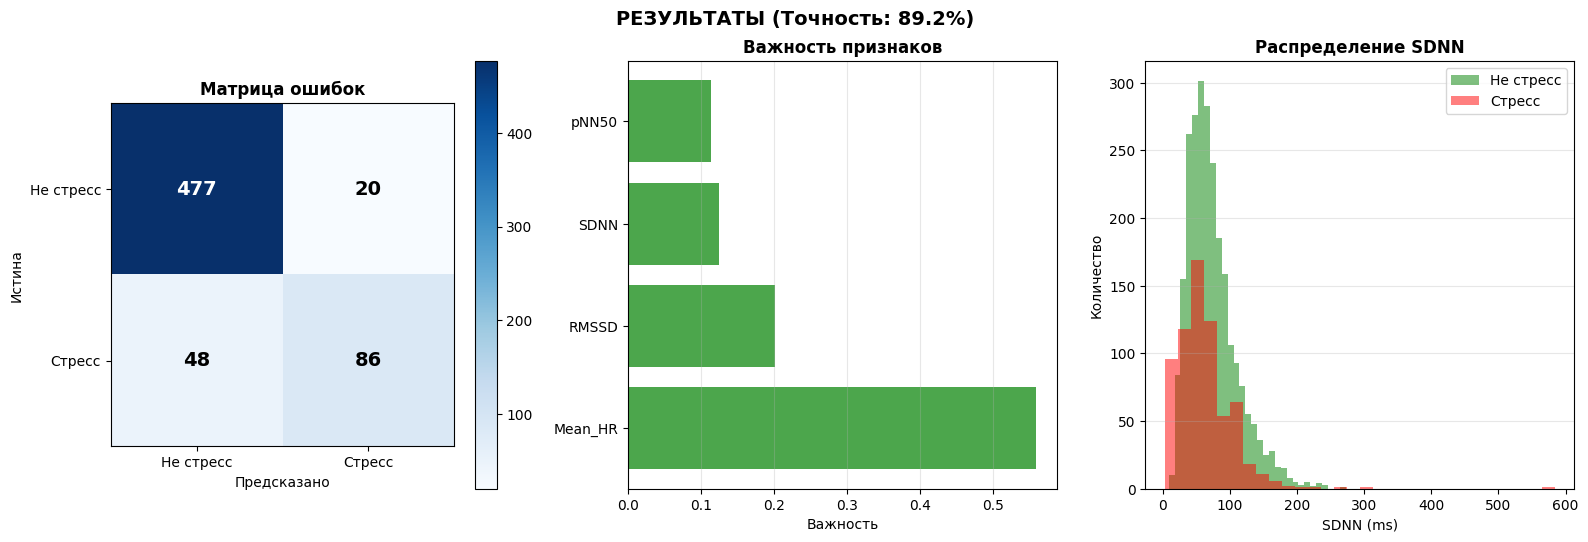

  ✅ Графики сохранены: outputs/all_subjects_results.png

✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!

📊 ИТОГИ:
  • Загружено субъектов: 15
  • Всего окон: 3152
  • Точность на тесте: 89.2%
  • CV точность: 89.7% ± 1.0%
  
🎯 ИНТЕРПРЕТАЦИЯ:
  ✅ ОТЛИЧНО! Модель хорошо различает стресс
  
  
    


In [15]:
def main():
    """Главная функция - здесь всё управляется"""
    
    print("\n")
    print("=" * 80)
    print("🎓 ОБУЧЕНИЕ МОДЕЛИ НА ВСЕХ СУБЪЕКТАХ WESAD".center(80))
    print("=" * 80)
    
    # ========================================================================
    # ШАГ 1: ЗАГРУЗКА ВСЕХ СУБЪЕКТОВ
    # ========================================================================
    
    print(f"\n📂 ЗАГРУЗКА ДАННЫХ ({len(SUBJECTS)} субъектов)...")
    print("-" * 80)
    
    all_X = []  # список массивов признаков
    all_y = []  # список массивов меток
    subject_ids = []  # отслеживаем, от кого каждое окно
    
    # Цикл: загружаем каждого субъекта
    for subject in SUBJECTS:
        X, y = load_subject(subject, window_size_sec=WINDOW_SIZE_SEC, fs=SAMPLING_RATE)
        
        if X is not None and y is not None:
            all_X.append(X)  # добавляем массив окон S2
            all_y.append(y)  # добавляем метки S2
            subject_ids.extend([subject] * len(X))  # говорим "все эти окна от S2"
    
    if len(all_X) == 0:
        print("\n❌ Не удалось загрузить ни одного субъекта!")
        print("   Проверь, что данные находятся в data/wesad/S2/S2.pkl и т.д.")
        return  # выходим из функции
    
    # Объединяем все субъекты в один большой массив
    X_all = np.vstack(all_X)  # vstack = vertically stack (стопка вертикально)
    y_all = np.hstack(all_y)  # hstack = horizontally stack

    print("\n" + "=" * 80)
    print("📊 ИТОГОВЫЙ ДАТАСЕТ:")
    print("=" * 80)
    print(f"  Всего окон: {len(X_all)}")
    print(f"  Стресс (1): {np.sum(y_all)} окон ({np.sum(y_all)/len(y_all)*100:.1f}%)")
    print(f"  Не стресс (0): {len(y_all)-np.sum(y_all)} окон ({(len(y_all)-np.sum(y_all))/len(y_all)*100:.1f}%)")
    print(f"  Признаков: {X_all.shape[1]} (SDNN, RMSSD, pNN50, Mean_HR)")
    
    # Статистика по признакам
    print("\n" + "=" * 80)
    print("📈 СТАТИСТИКА ПРИЗНАКОВ:")
    print("=" * 80)
    
    feature_names = ['SDNN', 'RMSSD', 'pNN50', 'Mean_HR']
    
    for label_id, label_name in [(0, 'Не стресс'), (1, 'Стресс')]:
        print(f"\n{label_name}:")
        
        mask = (y_all == label_id)  # выбираем только этого класса
        
        for i, name in enumerate(feature_names):
            mean_val = np.mean(X_all[mask, i])   # среднее
            std_val = np.std(X_all[mask, i])     # разброс
            print(f"  {name:10s}: {mean_val:7.2f} ± {std_val:6.2f}")

    print("\n" + "=" * 80)
    print("🔧 НОРМАЛИЗАЦИЯ ПРИЗНАКОВ...")
    print("=" * 80)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all)
    
    print("  ✅ Признаки нормализованы (mean=0, std=1)")


    print("\n" + "=" * 80)
    print("✂️  РАЗДЕЛЕНИЕ ДАННЫХ...")
    print("=" * 80)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_all, 
        test_size=0.2,      # 20% на тест, 80% на обучение
        random_state=42,    # для воспроизводимости
        stratify=y_all      # сохраняем пропорции классов
    )
    
    print(f"  Обучающая выборка: {len(X_train)} окон")
    print(f"  Тестовая выборка:  {len(X_test)} окон")


    print("\n" + "=" * 80)
    print("🤖 ОБУЧЕНИЕ МОДЕЛИ RandomForest...")
    print("=" * 80)
    
    model = RandomForestClassifier(
        n_estimators=200,      # 200 деревьев решений
        max_depth=15,          # глубина дерева (сложность)
        min_samples_split=10,  # минимум образцов для разделения
        min_samples_leaf=5,    # минимум образцов в листе
        random_state=42,
        n_jobs=-1,             # используем все ядра CPU
        verbose=1
    )
    
    model.fit(X_train, y_train)
    
    print("\n  ✅ Модель обучена!")
    print("\n" + "=" * 80)
    print("🔄 КРОСС-ВАЛИДАЦИЯ (5 фолдов)...")
    print("=" * 80)
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    print(f"  Точность по фолдам: {[f'{s*100:.1f}%' for s in cv_scores]}")
    print(f"  Средняя точность: {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%")
    print("\n" + "=" * 80)
    print("🎯 ТЕСТИРОВАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ...")
    print("=" * 80)
    
    # Предсказываем метки для тестовых данных
    y_pred = model.predict(X_test)
    
    # Считаем точность
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n  ✅ ТОЧНОСТЬ: {accuracy*100:.1f}%")
    
    # Матрица ошибок
    print(f"\n📊 МАТРИЦА ОШИБОК:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    # Детальный отчёт
    print(f"\n📋 КЛАССИФИКАЦИОННЫЙ ОТЧЁТ:")
    print(classification_report(y_test, y_pred, target_names=['Не стресс', 'Стресс']))
    print("\n" + "=" * 80)
    print("🔍 ВАЖНОСТЬ ПРИЗНАКОВ:")
    print("=" * 80)
    
    for i, name in enumerate(feature_names):
        importance = model.feature_importances_[i]
        print(f"  {name:10s}: {importance:.3f} {'█' * int(importance * 50)}")
    print("\n" + "=" * 80)
    print("📈 СОЗДАНИЕ ГРАФИКОВ...")
    print("=" * 80)
    
    fig = plt.figure(figsize=(16, 10))
    
    # ГРАФИК 1: Матрица ошибок
    ax1 = plt.subplot(2, 3, 1)
    im = ax1.imshow(cm, cmap='Blues')
    ax1.set_title('Матрица ошибок', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Предсказано')
    ax1.set_ylabel('Истина')
    ax1.set_xticks([0, 1])
    ax1.set_yticks([0, 1])
    ax1.set_xticklabels(['Не стресс', 'Стресс'])
    ax1.set_yticklabels(['Не стресс', 'Стресс'])
    
    # Добавляем числа в ячейки
    for i in range(2):
        for j in range(2):
            text = ax1.text(j, i, cm[i, j], 
                          ha="center", va="center",
                          color="w" if cm[i, j] > cm.max()/2 else "black",
                          fontweight='bold', fontsize=14)
    
    plt.colorbar(im, ax=ax1)
    # ГРАФИК 2: Важность признаков
    ax2 = plt.subplot(2, 3, 2)
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]  # сортируем
    
    ax2.barh(range(len(indices)), importances[indices], color='green', alpha=0.7)
    ax2.set_yticks(range(len(indices)))
    ax2.set_yticklabels([feature_names[i] for i in indices])
    ax2.set_xlabel('Важность')
    ax2.set_title('Важность признаков', fontweight='bold', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='x')
    # ГРАФИКИ 3-6: Распределение признаков
    ax3 = plt.subplot(2, 3, 3)
    ax3.hist(X_all[y_all==0, 0], bins=30, alpha=0.5, label='Не стресс', color='green')
    ax3.hist(X_all[y_all==1, 0], bins=30, alpha=0.5, label='Стресс', color='red')
    ax3.set_xlabel('SDNN (ms)')
    ax3.set_ylabel('Количество')
    ax3.set_title('Распределение SDNN', fontweight='bold', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    plt.suptitle(f'РЕЗУЛЬТАТЫ (Точность: {accuracy*100:.1f}%)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/all_subjects_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("  ✅ Графики сохранены: outputs/all_subjects_results.png")
    print("\n" + "=" * 80)
    print("✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
    print("=" * 80)
    
    print(f"""
📊 ИТОГИ:
  • Загружено субъектов: {len(all_X)}
  • Всего окон: {len(X_all)}
  • Точность на тесте: {accuracy*100:.1f}%
  • CV точность: {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%
  
🎯 ИНТЕРПРЕТАЦИЯ:
  {'✅ ОТЛИЧНО! Модель хорошо различает стресс' if accuracy > 0.8 else ''}
  {'😐 СРЕДНЕ. Попробуй добавить EDA/Resp сигналы' if 0.6 < accuracy <= 0.8 else ''}
  {'❌ ПЛОХО. Нужны дополнительные признаки' if accuracy <= 0.6 else ''}
    """)

if __name__ == '__main__':
    main()
